El valor inicial de Threshold en Fig.1 es: 127.5
El nuevo valor de Threshold en Fig.1 es: 62.803349795226
El valor inicial de Threshold en Fig.2 es: 127.5
El nuevo valor de Threshold en Fig.2 es: 65.13184737607699


/tmp/ipykernel_580006/1043224936.py:31: RuntimeWarning: overflow encountered in ubyte_scalars
  ti1 = (np.max(image1)+np.min(image1))/2  # Initial threshold value


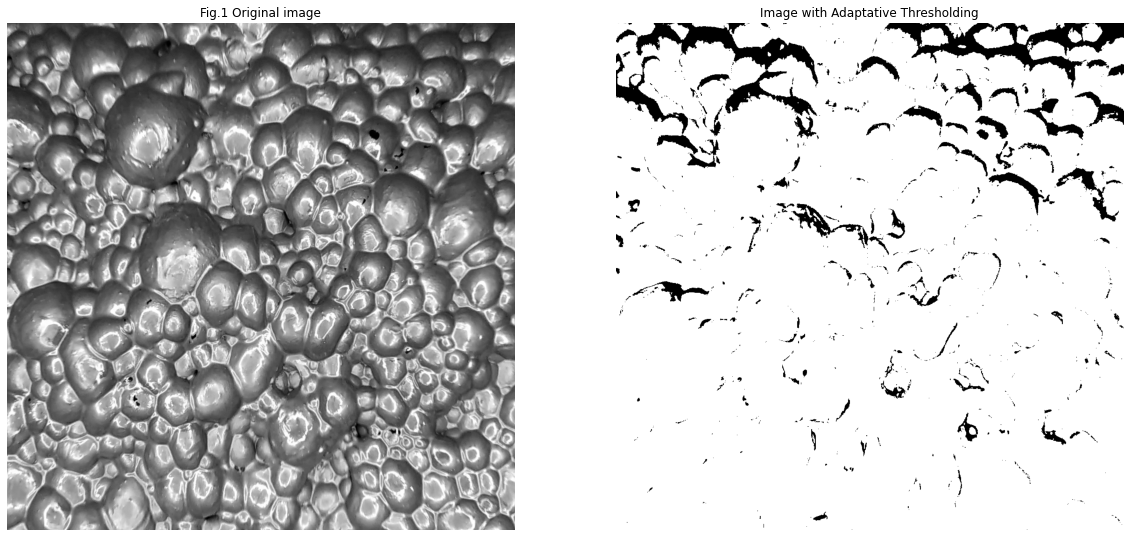

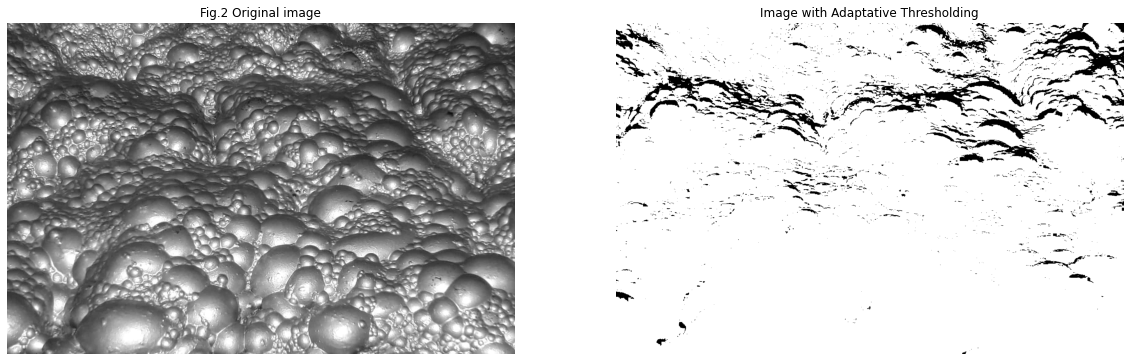

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from os import listdir, path
%matplotlib inline


def Adaptative_Thresholding(img, T0):
    # Binarized image at the inicial threshold value
    _, th = cv2.threshold(img, T0, 255, cv2.THRESH_BINARY)
    g1_u1 = np.mean(th*img)  # Compute the intensity averages μ1
    # Compute the intensity averages μ2
    g2_u2 = np.mean(cv2.bitwise_not(th)*img)
    NT = (g1_u1 + g2_u2)/2  # Compute a new threshold value
    if np.abs(NT - T0) > 1e-13:  # Difference in  T  between successive iterations
        return Adaptative_Thresholding(img, NT)  # Repeat steps 2-4
    else:
        # Binarized image at the new threshold value
        _, thNew = cv2.threshold(img, NT, 255, cv2.THRESH_BINARY)
        # Return binarized image with the new threshold value and new threshold value
        return thNew, NT


image = cv2.imread('./bubble_raw.png', 0)  # Load Image
ti = (np.max(image)+np.min(image))/2  # Initial threshold value
print('El valor inicial de Threshold en Fig.1 es:', ti)
bimg, newT = Adaptative_Thresholding(image, ti)  # Call function
print('El nuevo valor de Threshold en Fig.1 es:', newT)

image1 = cv2.imread('./froth_img.jpg', 0)  # Load Image
ti1 = (np.max(image1)+np.min(image1))/2  # Initial threshold value
print('El valor inicial de Threshold en Fig.2 es:', ti)
bimg1, newT1 = Adaptative_Thresholding(image1, ti1)  # Call function
print('El nuevo valor de Threshold en Fig.2 es:', newT1)

plt.figure(figsize=(20, 20))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Fig.1 Original image')
plt.axis('off')  # Display the image
plt.subplot(1, 2, 2)
plt.imshow(bimg, cmap='gray')
plt.title('Image with Adaptative Thresholding')
plt.axis('off')  # Display the image
plt.figure(figsize=(20, 20))
plt.subplot(1, 2, 1)
plt.imshow(image1, cmap='gray')
plt.title('Fig.2 Original image')
plt.axis('off')  # Display the image
plt.subplot(1, 2, 2)
plt.imshow(bimg1, cmap='gray')
plt.title('Image with Adaptative Thresholding')
plt.axis('off')  # Display the image
plt.show()
